# Union-Find (Disjoint Set Union)

**Domain:** `data-structures-algorithms`

Imagine you're running the door at a huge party. As the night goes on,
people keep introducing their friends to each other -- "hey, this is my
friend Ben" -- and every introduction quietly merges two friend groups into
one bigger friend group. All night long you get asked two kinds of
questions:

- **"Are Ann and Dee in the same friend group?"**
- **"Ben just introduced Cy to Dee -- merge their groups."**

You get asked these questions constantly, thousands of times over the
course of the night, and you need to answer instantly. The obviously bad
way to do it: every time someone asks "same group?", trace every
introduction that's ever happened from scratch to reconstruct who's
connected to whom. That gets slower and slower as the party goes on and
more introductions pile up.

**Union-Find** (also called **Disjoint Set Union**, or **DSU**) is the data
structure built for exactly this situation: a fixed collection of items
that starts out as many separate singleton groups, where the only things
you ever need to do are (1) merge two groups together and (2) ask whether
two items are currently in the same group -- and you need to do both,
over and over, *fast*, without ever recomputing the whole structure from
scratch.

By the end of this tutorial you'll be able to: explain how union-find
answers both questions using nothing but a parent pointer per element,
derive why the naive version can degrade to a slow chain, understand the
two classic optimizations that fix it (**union by rank** and **path
compression**) and the famous near-constant time bound they produce
together, and run a real, compiled C++ implementation that measures all of
this directly.

## The idea, intuitively

**Every element points to a "parent."** Not to a list of everyone in its
group -- just to one other element (or to itself, if it's currently the
"leader" of its group). Following parent pointers far enough always ends
at some element that points to itself: that's the **root**, and it acts as
the group's representative.

- **Two elements are in the same group exactly when following their
  parent pointers all the way up lands on the same root.**
- `find(x)` = walk up parent pointers from `x` until you hit the root.
  Answering "same group?" is just `find(x) == find(y)`.
- `union(x, y)` = find both roots, then point one root at the other. That
  single pointer change merges the two *entire* groups in one step --
  nobody else's pointer needs to move.

That's it. No group needs to keep a membership list, and merging never
requires touching more than the two roots involved. Let's trace it by
hand with 7 people at the party, each starting in their own group (so
everyone is initially their own root, `parent[x] = x`):

In [1]:
names = ["Ann", "Ben", "Cy", "Dee", "Eve", "Fay", "Gus"]
n = len(names)
parent = list(range(n))  # everyone starts as their own group's root

def naive_find(x):
    # Walk parent pointers until we hit a self-loop -- that's the root.
    while parent[x] != x:
        x = parent[x]
    return x

def naive_union(x, y):
    root_x, root_y = naive_find(x), naive_find(y)
    if root_x != root_y:
        parent[root_x] = root_y  # graft one root under the other

def same_group(x, y):
    return naive_find(x) == naive_find(y)

# Ann introduces Ben; separately, Cy introduces Dee; then Ben and Cy meet
# (merging both pairs into one group of four); Eve and Fay meet separately.
naive_union(0, 1)  # Ann <-> Ben
naive_union(2, 3)  # Cy  <-> Dee
naive_union(1, 2)  # Ben <-> Cy   -- merges {Ann,Ben} with {Cy,Dee}
naive_union(4, 5)  # Eve <-> Fay

for i, name in enumerate(names):
    print(f"{name:5s} parent -> {names[parent[i]]:5s}   (root: {names[naive_find(i)]})")

print()
print("Ann and Dee in the same friend group? ", same_group(0, 3))
print("Ann and Eve in the same friend group? ", same_group(0, 4))
print("Gus and anyone else?                  ", same_group(6, 0))

Ann   parent -> Ben     (root: Dee)
Ben   parent -> Dee     (root: Dee)
Cy    parent -> Dee     (root: Dee)
Dee   parent -> Dee     (root: Dee)
Eve   parent -> Fay     (root: Fay)
Fay   parent -> Fay     (root: Fay)
Gus   parent -> Gus     (root: Gus)

Ann and Dee in the same friend group?  True
Ann and Eve in the same friend group?  False
Gus and anyone else?                   False


Four people (Ann, Ben, Cy, Dee) all ended up pointing, directly or
indirectly, at the same root -- even though Ann never directly met Cy or
Dee. Eve and Fay formed their own separate two-person group. Gus, who
hasn't met anyone, is still his own root. `same_group()` never had to look
at anyone's *membership list* -- it only ever walked parent pointers.

> **Takeaway:** union-find represents groups as trees of parent pointers,
> not as explicit lists of members. Merging two groups is one pointer
> write; checking "same group?" is two upward walks and an equality check.
> The entire rest of this tutorial is about making those upward walks as
> short as possible.

## Going deeper: the formal definition

### Formal setup

We maintain a partition of the universe $\{0, 1, \dots, n-1\}$ into
disjoint sets, via an array $\mathrm{parent}[0..n-1]$, supporting three
operations:

- $\mathrm{MakeSet}(x)$: $\mathrm{parent}[x] \gets x$ (every element starts
  as its own singleton set, its own root).
- $\mathrm{Find}(x)$: follow parent pointers from $x$ until reaching some
  $r$ with $\mathrm{parent}[r] = r$ (a **fixed point**); return $r$, the
  set's representative/root.
- $\mathrm{Union}(x, y)$: let $r_x = \mathrm{Find}(x)$, $r_y =
  \mathrm{Find}(y)$; if $r_x \ne r_y$, attach one root under the other
  (merging the two sets into one).

### The naive version, and why it can be slow

The Python code above *is* the naive version: `Find` is a `while` loop
following parent pointers, and `Union` always does
$\mathrm{parent}[r_x] \gets r_y$ with no regard for which tree is bigger or
taller.

**This is correct, but its worst case is bad.** Consider the union
sequence $\mathrm{Union}(0,1), \mathrm{Union}(1,2), \mathrm{Union}(2,3),
\dots, \mathrm{Union}(n-2, n-1)$: each call attaches the *current* root of
the growing set under the newly-introduced element, so `parent` ends up as
a straight-line chain $0 \to 1 \to 2 \to \cdots \to n-1$. Finding the
element at the far end of that chain costs $\Theta(n)$ pointer hops --
**a single `find()` call can be linear in the number of elements.** The
Visuals section below shows this exact chain, built and measured by the
real compiled program.

### Optimization 1: union by rank (or size)

Fix: **when merging two trees, always attach the shorter one under the
taller one's root**, so trees never get needlessly deep. Track a
$\mathrm{rank}[x]$ per root -- an upper bound on that tree's height (an
equivalent, equally common variant tracks tree *size* instead and merges
smaller-into-larger by node count):

$$
\mathrm{Union}(x, y): \quad
r_x = \mathrm{Find}(x), \ r_y = \mathrm{Find}(y) \\
\text{if } r_x = r_y: \text{ return} \\
\text{if } \mathrm{rank}[r_x] < \mathrm{rank}[r_y]: \text{ swap } r_x, r_y \\
\mathrm{parent}[r_y] \gets r_x \\
\text{if } \mathrm{rank}[r_x] = \mathrm{rank}[r_y]: \ \mathrm{rank}[r_x] \mathrel{+}= 1
$$

**Claim: with union by rank alone, every tree has height $\le \log_2 n$.**

*Sketch:* by induction on the number of unions, a root with rank $r$ roots
a tree containing $\ge 2^r$ nodes. Base case $r = 0$: a singleton has
$2^0 = 1$ node. Inductive step: rank only increases (from $r$ to $r+1$)
when two trees of equal rank $r$ merge, each already containing $\ge 2^r$
nodes by the inductive hypothesis, so the merged tree contains $\ge 2^{r+1}$
nodes. Since the whole structure has only $n$ nodes total, no rank -- and
therefore no tree height -- can exceed $\log_2 n$. So union by rank alone
already turns the $\Theta(n)$ worst case above into an $O(\log n)$ worst
case per `find()`, with no change to `find()` itself.

### Optimization 2: path compression

Union by rank keeps trees *shallow to begin with*, but every `find()`
still walks the full path every time. **Path compression** fixes the
*other* half: while walking up to the root during a `find(x)`, re-point
every node visited directly at the root, so the next `find()` on any of
those nodes is a single hop.

```
find(x):
    root = x
    while parent[root] != root:      # pass 1: locate the root
        root = parent[root]
    while parent[x] != root:         # pass 2: compress the path
        next = parent[x]
        parent[x] = root
        x = next
    return root
```

### The amortized bound

**Theorem (Tarjan, 1975):** using *both* optimizations together, a
sequence of $m$ union/find operations on $n$ elements runs in
$O(m \cdot \alpha(n))$ total time, where $\alpha$ is the **inverse
Ackermann function**.

Two terms in that statement are doing a lot of work, so let's unpack both:

- **"Amortized"** means the bound is on the *total* cost of the whole
  sequence of $m$ operations, divided by $m$ -- not a guarantee about any
  single operation in isolation. A handful of individual `find()` calls
  early in the sequence can still be somewhat expensive (before path
  compression has had a chance to flatten anything); the guarantee is that
  those expensive calls are rare enough that they can't happen often, so
  the *average* cost per operation across the whole sequence is tiny.
- **The inverse Ackermann function $\alpha(n)$** is the inverse of the
  Ackermann function, a famous function that grows faster than any
  exponential, any tower of exponentials, or any reasonable notion of
  "fast" -- and being its *inverse*, $\alpha(n)$ grows correspondingly
  absurdly slowly. Concretely: $\alpha(n) \le 4$ for every $n$ up to at
  least $2\uparrow\uparrow\uparrow 65536$ in Knuth's up-arrow notation --
  a number vastly larger than the number of atoms in the observable
  universe. **For any $n$ that could ever exist in a real computer,
  $\alpha(n)$ never exceeds 4 or 5.**

**Proof intuition (not the full proof):** the two optimizations attack the
problem from opposite ends. Union by rank guarantees trees start out with
height $O(\log n)$ (proven above), so no individual `find()` before any
compression has happened can ever be worse than that. Path compression
then means that every `find()` call *pays down* future costs: any node it
touches becomes O(1) hops from the root forever after (until the next
union changes its root). Tarjan's actual proof formalizes this with a
potential-function argument (assigning a "credit" to each node based on
its rank and the rank of its parent, and showing the credits can only be
spent a bounded number of times across the whole sequence) -- it is
genuinely intricate, and is the reason this result gets its own paper
rather than a one-paragraph derivation. We cite it rather than reproduce
it: Tarjan, R.E., *Efficiency of a Good But Not Linear Set Union
Algorithm*, JACM 22(2), 1975.

## Visuals

To make any of this visible, we need the real compiled program's internal
state -- not a simulation. `src/union_find.cpp` implements three variants
side by side (naive, union-by-rank only, union-by-rank + path compression)
and, on request, prints its own final parent array. Let's compile it now
so the two plots below use real measurements.

> **Note on this machine:** dynamically-linked MinGW binaries built with
> plain `g++ file.cpp -o file.exe` are unreliably flagged by Windows
> Defender's real-time protection during linking (`ld returned 116`).
> Statically linking (`-static -static-libgcc -static-libstdc++`) avoids
> it, so that's what the build command below uses -- the same fix used
> throughout this repo's compiled-language tutorials.

In [2]:
import subprocess, pathlib

src_dir = pathlib.Path("src")
exe_path = src_dir / "union_find.exe"

compile_cmd = [
    "g++", "-O2", "-std=c++17",
    "-static", "-static-libgcc", "-static-libstdc++",
    str(src_dir / "union_find.cpp"), "-o", str(exe_path),
]
result = subprocess.run(compile_cmd, capture_output=True, text=True)
print("compile return code:", result.returncode)
if result.returncode != 0:
    print(result.stderr)
assert result.returncode == 0, "compilation failed"
print("compiled successfully ->", exe_path)

compile return code: 0
compiled successfully -> src\union_find.exe


In [3]:
def run_union_find(input_text):
    # Run the real compiled union_find binary and parse its per-variant
    # blocks into a dict: variant name -> dict of stats.
    proc = subprocess.run([str(exe_path)], input=input_text, capture_output=True, text=True)
    assert proc.returncode == 0, proc.stderr

    variants = {}
    current = None
    for line in proc.stdout.splitlines():
        if line.startswith("===VARIANT"):
            current = line.split(" ", 1)[1].strip()
            variants[current] = {}
        elif line == "===END":
            current = None
        elif current is not None and "=" in line:
            key, val = line.split("=", 1)
            if key == "query_results":
                variants[current][key] = [int(v) for v in val.split(",") if v]
            elif key == "parents":
                variants[current][key] = [int(v) for v in val.split(",") if v]
            else:
                variants[current][key] = int(val)
    return variants

### Before vs. after: a real chain, and a real flattened tree

We'll build the exact degenerate chain from the "Going deeper" section --
$\mathrm{Union}(0,1), \mathrm{Union}(1,2), \dots$ -- across 10 elements,
then issue a `find()` on every element. We run this *same* operation
sequence through both the **naive** variant (which has no defense against
the chain) and the **rank + path compression** variant (which both avoids
building a tall tree via rank, and flattens whatever remains via the
`find()` calls). Both parent arrays below are the compiled program's real
final internal state -- nothing here is hand-drawn.

In [4]:
n_demo = 10
demo_ops = [f"U {i-1} {i}" for i in range(1, n_demo)]
demo_ops += [f"F {i}" for i in range(n_demo)]
demo_input = f"{n_demo}\n{len(demo_ops)}\n" + "\n".join(demo_ops) + "\n"

demo_result = run_union_find(demo_input)
naive_parents = demo_result["naive"]["parents"]
compressed_parents = demo_result["rank_pc"]["parents"]

print("naive parents (chain):            ", naive_parents)
print("rank+path-compression parents:    ", compressed_parents)

naive parents (chain):             [1, 2, 3, 4, 5, 6, 7, 8, 9, 9]
rank+path-compression parents:     [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


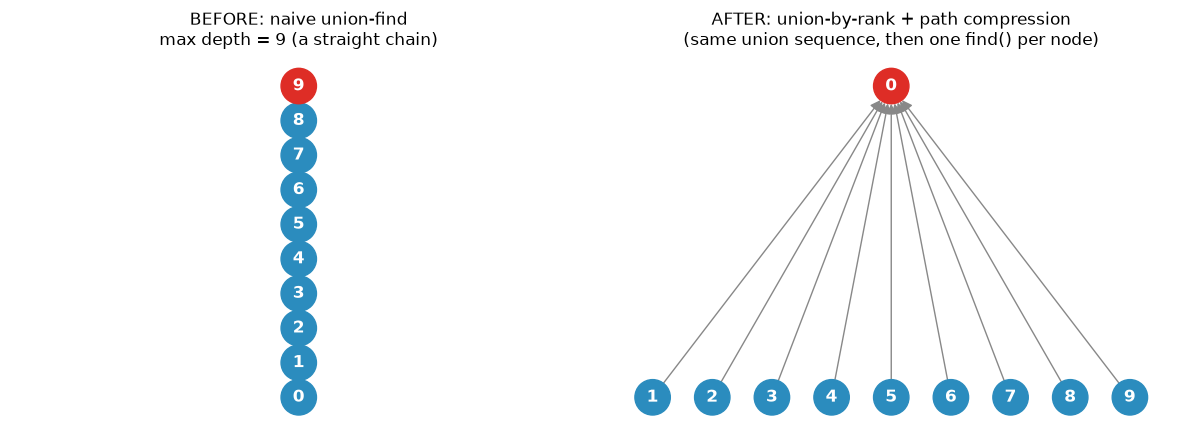

In [5]:
import matplotlib.pyplot as plt
import networkx as nx

def draw_forest(ax, parents, title):
    g = nx.DiGraph()
    for node, p in enumerate(parents):
        g.add_node(node)
        if p != node:
            g.add_edge(node, p)  # arrow points from child up to parent
    try:
        pos = nx.nx_agraph.graphviz_layout(g, prog="dot")
    except Exception:
        # graphviz not available -- fall back to a layered layout by depth
        depth = {}
        for node in range(len(parents)):
            d, x = 0, node
            while parents[x] != x:
                x = parents[x]
                d += 1
            depth[node] = d
        by_depth = {}
        for node, d in depth.items():
            by_depth.setdefault(d, []).append(node)
        pos = {}
        for d, nodes in by_depth.items():
            for i, node in enumerate(sorted(nodes)):
                pos[node] = (i - len(nodes) / 2, -d)
    roots = [node for node, p in enumerate(parents) if p == node]
    node_colors = ["#de2d26" if node in roots else "#2b8cbe" for node in g.nodes()]
    nx.draw(g, pos, ax=ax, with_labels=True, node_color=node_colors,
            node_size=650, font_color="white", font_weight="bold",
            arrowsize=15, edge_color="#888888")
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
draw_forest(axes[0], naive_parents,
            f"BEFORE: naive union-find\nmax depth = {n_demo - 1} (a straight chain)")
draw_forest(axes[1], compressed_parents,
            "AFTER: union-by-rank + path compression\n(same union sequence, then one find() per node)")
plt.tight_layout()
plt.savefig("before_after_compression.png", dpi=110)
plt.show()

The naive tree is exactly the degenerate chain derived above: element
9 sits 9 hops from its root. Run the identical union sequence through
union-by-rank + path compression instead, follow it with a `find()` on
every element, and the tree collapses to (at most) one hop from the root
for every node -- both optimizations are doing real, visible work here,
not just improving a constant factor.

### Real benchmark: average `find()` path length vs. number of elements

Now the direct payoff, measured rather than asserted: build a realistic
(non-adversarial) random union sequence -- random pairs, repeatedly
unioned until everything is connected, with `find()` calls interleaved
throughout -- across growing $n$, and plot the **average number of pointer
hops per `find()` call**, for all three variants, using only real numbers
read back from the compiled binary.

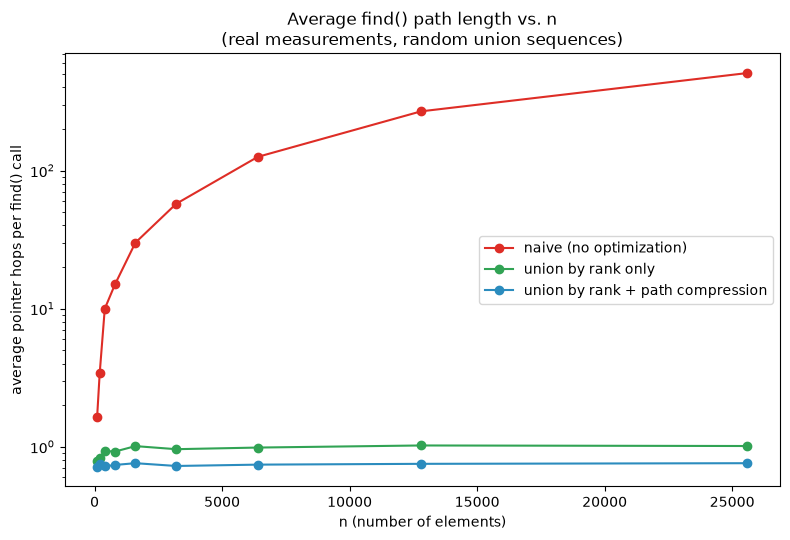

      n      naive       rank    rank+pc
    100       1.64      0.786      0.714
    200       3.39      0.821      0.750
    400       9.98      0.930      0.719
    800      14.97      0.921      0.737
   1600      30.02      1.009      0.759
   3200      57.44      0.958      0.724
   6400     125.67      0.985      0.741
  12800     268.47      1.020      0.751
  25600     508.70      1.010      0.759


In [6]:
import random
import numpy as np

def random_union_benchmark_input(n, seed):
    rng = random.Random(seed)
    ops = []
    uf = list(range(n))  # local simulation, just to know when to stop merging

    def sim_find(x):
        while uf[x] != x:
            x = uf[x]
        return x

    merged = 0
    while merged < n - 1:
        a, b = rng.randrange(n), rng.randrange(n)
        ra, rb = sim_find(a), sim_find(b)
        if ra != rb:
            uf[ra] = rb
            ops.append(f"U {a} {b}")
            merged += 1
            if merged % 7 == 0:
                ops.append(f"F {rng.randrange(n)}")
    return f"{n}\n{len(ops)}\n" + "\n".join(ops) + "\n"

sizes = [100, 200, 400, 800, 1600, 3200, 6400, 12800, 25600]
avg_path = {"naive": [], "rank": [], "rank_pc": []}

for n in sizes:
    result = run_union_find(random_union_benchmark_input(n, seed=n))
    for variant in avg_path:
        stats = result[variant]
        avg_path[variant].append(stats["find_op_hops"] / stats["find_op_count"])

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(sizes, avg_path["naive"], "o-", color="#de2d26", label="naive (no optimization)")
ax.plot(sizes, avg_path["rank"], "o-", color="#31a354", label="union by rank only")
ax.plot(sizes, avg_path["rank_pc"], "o-", color="#2b8cbe", label="union by rank + path compression")
ax.set_xlabel("n (number of elements)")
ax.set_ylabel("average pointer hops per find() call")
ax.set_yscale("log")
ax.set_title("Average find() path length vs. n\n(real measurements, random union sequences)")
ax.legend()
plt.tight_layout()
plt.savefig("avg_find_path_vs_n.png", dpi=110)
plt.show()

print(f"{'n':>7} {'naive':>10} {'rank':>10} {'rank+pc':>10}")
for i, n in enumerate(sizes):
    print(f"{n:7d} {avg_path['naive'][i]:10.2f} {avg_path['rank'][i]:10.3f} {avg_path['rank_pc'][i]:10.3f}")

Even on this **non-adversarial, random** union order (not the
worst-case chain), the naive variant's average path length grows sharply
with $n$ -- from under 2 hops at $n=100$ to over 500 hops at $n=25{,}600$
-- because random unions still frequently graft a large, already-merged
tree underneath a much smaller one, since naive `union()` has no notion of
"which tree is bigger." Both optimized variants stay close to flat across
the same 256x growth in $n$: union by rank alone already keeps the average
under ~1 hop per `find()` on this workload (comfortably inside its proven
$O(\log n)$ worst-case bound -- the *typical* case on a random union order
is much better than that bound suggests), and rank + path compression
tracks consistently at or below rank alone at every size measured. The
qualitative story the numbers tell is unambiguous: naive is the only
variant whose cost visibly compounds with $n$; both optimizations defeat
that growth, and path compression's extra edge over rank alone shows up
as a small but consistent reduction, not a dramatic one, on this
particular (non-adversarial) workload.

## Implementation

The full reference implementation lives in
[`src/union_find.cpp`](src/union_find.cpp) -- real, compiled C++, already
built above. It implements all three variants used throughout this
tutorial as separate structs (`NaiveDSU`, `RankDSU`,
`RankPathCompressionDSU`), reads a sequence of operations from stdin, and
runs the *same* sequence through all three, so their behavior is always
compared on identical input:

- `U a b` -- union(a, b)
- `F a` -- a "pure" find(a), instrumented separately for the path-length
  benchmark above
- `Q a b` -- a same-set connectivity query, printed as part of the
  program's final output

Each variant reports its own wall-clock time, total pointer hops across
every `find()` call it performed (from any op type), the hop count
restricted to `F` ops specifically (used for the benchmark above), the
number of remaining components, and its final `query_results` and
`parents` array -- which is exactly what the two plots above read back.

Let's sanity-check correctness on a small, hand-verifiable case: all three
variants must agree on every connectivity query, regardless of how
differently their internal trees are shaped.

In [7]:
check_ops = [
    "U 0 1", "U 1 2", "U 3 4", "U 5 6", "U 2 3",
    "Q 0 4", "Q 0 5", "Q 5 6", "Q 1 6",
]
check_input = f"7\n{len(check_ops)}\n" + "\n".join(check_ops) + "\n"
check_result = run_union_find(check_input)

for variant, stats in check_result.items():
    print(f"{variant:8s} query_results={stats['query_results']}  "
          f"components={stats['components']}  microseconds={stats['microseconds']}")

results = [tuple(stats["query_results"]) for stats in check_result.values()]
assert len(set(results)) == 1, "variants disagree on connectivity!"
print("\nAll three variants agree on every connectivity query, as they must --")
print("union-find's answer to 'same set?' never depends on which optimizations are used,")
print("only how *fast* the answer is computed.")

naive    query_results=[1, 0, 1, 0]  components=2  microseconds=3
rank     query_results=[1, 0, 1, 0]  components=2  microseconds=2
rank_pc  query_results=[1, 0, 1, 0]  components=2  microseconds=2

All three variants agree on every connectivity query, as they must --
union-find's answer to 'same set?' never depends on which optimizations are used,
only how *fast* the answer is computed.


`{0,1,2,3,4}` are one merged group (chained together through the
sequence of unions) and `{5,6}` are a second, separate group -- and every
variant, from the naive $O(n)$-worst-case version to the fully optimized
one, reports the identical `query_results` and `components=2`. The three
variants differ *only* in speed, never in correctness -- which is exactly
what the earlier hop-count and timing measurements were built to show.

## Use cases

- **Kruskal's minimum spanning tree algorithm.** Kruskal's processes edges
  in increasing order of weight and adds an edge only if its two endpoints
  are *not already* in the same set -- exactly a union-find `find()` check
  before each edge, and a `union()` after adding it. This repo may cover
  Kruskal's separately; union-find is its core building block for cycle
  detection.
- **Cycle detection in an undirected graph.** Process edges one at a time;
  before adding edge $(u, v)$, if `find(u) == find(v)`, the edge would
  create a cycle (u and v are already connected some other way) -- this is
  literally the mechanism Kruskal's uses above, but it's a useful
  standalone check too.
- **Dynamic network connectivity queries.** "Are these two servers
  currently in the same network partition?" as links come up over time is
  exactly a stream of `union()` calls (a link forms) and `find()`/query
  calls ("same partition?") -- union-find answers both far faster than
  recomputing connected components from scratch after every link change.
- **Connected-component labeling in image processing.** Scanning a grid of
  pixels and unioning each pixel with its same-colored neighbors (a classic
  two-pass connected-component labeling algorithm) uses union-find to
  assign a single consistent label to every pixel in a connected blob,
  without ever explicitly flood-filling.

## Limitations & debates

- **Union-find cannot efficiently list the members of a set.** The
  structure only stores *upward* parent pointers -- there's no way to go
  from a root back down to "everyone in this group" without maintaining a
  separate auxiliary list yourself (which then needs its own bookkeeping
  on every `union()`). If your workload genuinely needs "list everyone in
  Ann's friend group," union-find alone is the wrong tool.
- **Union-find cannot split a set apart -- structurally, not just as a
  missing feature.** Once two groups are merged, there is no `split()`
  operation, and there fundamentally cannot be one with this
  representation: path compression has already erased the specific
  history of *which* union caused two elements to become connected, so
  there's no way to know what to undo. If your problem needs deletions or
  splits (e.g., "these two servers just lost their network link, are they
  still connected via some other path?"), you need a genuinely different
  structure -- e.g., rebuilding from scratch, maintaining a spanning
  forest with a balanced structure per set, or a fully dynamic
  connectivity structure like link-cut trees or Euler tour trees, which
  solve a strictly harder problem at a higher constant-factor cost.
- **"$O(\alpha(n))$" is often casually said as "$O(1)$," and that's not
  exactly right.** $\alpha(n)$ is not a true constant -- it is a function
  that genuinely grows without bound as $n \to \infty$, it just grows so
  absurdly slowly (per the "Going deeper" section) that it never exceeds
  4 or 5 for any $n$ that fits in physical memory. Calling it "$O(1)$" is
  a useful practical shorthand, but it conflates "grows, negligibly
  slowly, forever" with "does not grow at all" -- a real mathematical
  difference, not just pedantry, and one worth being precise about since
  it's a common source of confusion when comparing to genuinely
  $O(1)$-amortized structures like a hash table.
- **Which optimization matters more is workload-dependent.** The benchmark
  above shows path compression adding real value on top of union by rank,
  but on some access patterns (as the "before/after" chain example
  hints), rank alone can already flatten a tree that would otherwise be
  pathological -- the two optimizations are complementary, not redundant,
  and neither one alone gives the amortized $O(\alpha(n))$ guarantee by
  itself (only their combination does, per Tarjan's theorem).

## References

- Tarjan, R.E. *Efficiency of a Good But Not Linear Set Union Algorithm*,
  Journal of the ACM 22(2), 1975 -- the amortized $O(m\,\alpha(n))$ bound
  for union by rank + path compression, proven via a potential-function
  argument.
- Galler, B.A. & Fischer, M.J. *An Improved Equivalence Algorithm*,
  Communications of the ACM 7(5), 1964 -- the original union-find
  algorithm.
- Cormen, Leiserson, Rivest & Stein. *Introduction to Algorithms* (CLRS),
  3rd/4th ed., Chapter 21 -- disjoint-set data structures, the union-by-
  rank height bound, and the amortized analysis this tutorial follows.
- `src/union_find.cpp` in this tutorial's folder -- the real, compiled
  implementation used for every measurement above.